In [39]:
from ax.service.ax_client import AxClient
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import ax
import matplotlib.ticker as mticker
import matplotlib.colors as mcolors
import matplotlib.cm as cm


import sys
sys.path.append('20250718_SAASBO/')
import helper_functions as hf

In [40]:
n=21

In [41]:
ax_client_file_path = f"/Users/zeqing/0_Github/drug_surfactant/experiments/20250718_SAASBO/iteration_{n}/optimizer/optimizer_{n}_loaded.json"

In [42]:
ax_client = AxClient.load_from_json_file(ax_client_file_path)
df = ax_client.get_trials_data_frame()
df['surf_conc'] = df['surf_1_conc'] + df['surf_2_conc'] + df['surf_3_conc']
df

,trial_index,arm_name,trial_status,generation_node,obj_surf_conc,Drug_MW,Drug_LogP,Drug_TPSA,surf_1,surf_1_conc,surf_2,surf_2_conc,surf_3,surf_3_conc,drug_conc,surf_conc
0,0,0_0,COMPLETED,None,100.0,0.2063,0.3073,0.0373,s8,12,s6,39,s7,20,25.0,71
1,1,1_0,COMPLETED,None,95.0,0.2063,0.3073,0.0373,s3,51,s2,4,s6,40,25.0,95
2,2,2_0,COMPLETED,None,100.0,0.4045,0.4196,0.0728,s5,1,s7,56,s3,0,25.0,57
3,3,3_0,COMPLETED,None,100.0,0.4045,0.4196,0.0728,s3,28,s3,6,s8,14,25.0,48
4,4,4_0,COMPLETED,None,100.0,0.2962,0.4364,0.0493,s1,27,s4,63,s5,3,25.0,93
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
111,111,111_0,COMPLETED,GenerationStep_2,100.0,0.3528,0.2810,0.0711,s1,0,s5,14,s7,16,25.0,30
112,112,112_0,COMPLETED,GenerationStep_2,52.0,0.2063,0.3073,0.0373,s1,49,s3,0,s6,3,25.0,52
113,113,113_0,COMPLETED,GenerationStep_2,100.0,0.4045,0.4196,0.0728,s1,12,s3,0,s6,61,25.0,73
114,114,114_0,COMPLETED,GenerationStep_2,51.0,0.2962,0.4364,0.0493,s1,12,s3,0,s7,39,25.0,51


In [43]:
# conc_to_convert = ['surf_1_conc', 'surf_2_conc', 'surf_3_conc', 'surf_conc', 'obj_surf_conc']
# df[conc_to_convert] = df[conc_to_convert]/100 * hf.actual_surfactant_stock_conc

In [44]:
df[df['trial_index']==89]

,trial_index,arm_name,trial_status,generation_node,obj_surf_conc,Drug_MW,Drug_LogP,Drug_TPSA,surf_1,surf_1_conc,surf_2,surf_2_conc,surf_3,surf_3_conc,drug_conc,surf_conc
89,89,89_0,COMPLETED,GenerationStep_2,100.0,0.4045,0.4196,0.0728,s6,26,s5,2,s5,26,25.0,54


In [45]:
def assign_iterations(n_rows, initial=32, following=4):
    # how many full “following” batches you’ll need after the initial one
    if n_rows <= initial:
        sizes = [n_rows]
    else:
        n_follow = int(np.ceil((n_rows - initial) / following))
        # build a list of batch‐sizes: [initial, following, following, …]
        sizes = [initial] + [following]*n_follow
    # repeat iteration numbers 0,1,2,… by the sizes, then truncate to n_rows
    iters = np.repeat(np.arange(len(sizes)), sizes)[:n_rows]
    return iters.astype(int)

# usage
df['iteration'] = assign_iterations(len(df))


#df['iteration'] = df['iteration'].astype(str)


df

,trial_index,arm_name,trial_status,generation_node,obj_surf_conc,Drug_MW,Drug_LogP,Drug_TPSA,surf_1,surf_1_conc,surf_2,surf_2_conc,surf_3,surf_3_conc,drug_conc,surf_conc,iteration
0,0,0_0,COMPLETED,None,100.0,0.2063,0.3073,0.0373,s8,12,s6,39,s7,20,25.0,71,0
1,1,1_0,COMPLETED,None,95.0,0.2063,0.3073,0.0373,s3,51,s2,4,s6,40,25.0,95,0
2,2,2_0,COMPLETED,None,100.0,0.4045,0.4196,0.0728,s5,1,s7,56,s3,0,25.0,57,0
3,3,3_0,COMPLETED,None,100.0,0.4045,0.4196,0.0728,s3,28,s3,6,s8,14,25.0,48,0
4,4,4_0,COMPLETED,None,100.0,0.2962,0.4364,0.0493,s1,27,s4,63,s5,3,25.0,93,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
111,111,111_0,COMPLETED,GenerationStep_2,100.0,0.3528,0.2810,0.0711,s1,0,s5,14,s7,16,25.0,30,20
112,112,112_0,COMPLETED,GenerationStep_2,52.0,0.2063,0.3073,0.0373,s1,49,s3,0,s6,3,25.0,52,21
113,113,113_0,COMPLETED,GenerationStep_2,100.0,0.4045,0.4196,0.0728,s1,12,s3,0,s6,61,25.0,73,21
114,114,114_0,COMPLETED,GenerationStep_2,51.0,0.2962,0.4364,0.0493,s1,12,s3,0,s7,39,25.0,51,21


In [46]:
# build maps from normalized MW → abbreviation and full name
abbr_map = {
    props["normalized_properties"]["Drug_MW"]: abbr
    for abbr, props in hf.normalize_drug_properties_dict.items()
}
full_map = {
    props["normalized_properties"]["Drug_MW"]: props["full_name"]
    for props in hf.normalize_drug_properties_dict.values()
}

# add the two new columns
df["drug_name"] = df["Drug_MW"].map(abbr_map)
df["drug_full"] = df["Drug_MW"].map(full_map)

df.head(18)

,trial_index,arm_name,trial_status,generation_node,obj_surf_conc,Drug_MW,Drug_LogP,Drug_TPSA,surf_1,surf_1_conc,surf_2,surf_2_conc,surf_3,surf_3_conc,drug_conc,surf_conc,iteration,drug_name,drug_full
0,0,0_0,COMPLETED,None,100.0,0.2063,0.3073,0.0373,s8,12,s6,39,s7,20,25.0,71,0,IBP,Ibuprofen
1,1,1_0,COMPLETED,None,95.0,0.2063,0.3073,0.0373,s3,51,s2,4,s6,40,25.0,95,0,IBP,Ibuprofen
2,2,2_0,COMPLETED,None,100.0,0.4045,0.4196,0.0728,s5,1,s7,56,s3,0,25.0,57,0,LOV,Lovastatin
3,3,3_0,COMPLETED,None,100.0,0.4045,0.4196,0.0728,s3,28,s3,6,s8,14,25.0,48,0,LOV,Lovastatin
4,4,4_0,COMPLETED,None,100.0,0.2962,0.4364,0.0493,s1,27,s4,63,s5,3,25.0,93,0,DCF,Diclofenac
5,5,5_0,COMPLETED,None,91.0,0.2962,0.4364,0.0493,s6,40,s8,29,s7,22,25.0,91,0,DCF,Diclofenac
6,6,6_0,COMPLETED,None,100.0,0.3528,0.2810,0.0711,s1,5,s1,24,s6,18,25.0,47,0,GLV,Griseofulvin
7,7,7_0,COMPLETED,None,100.0,0.3528,0.2810,0.0711,s6,10,s5,1,s1,36,25.0,47,0,GLV,Griseofulvin
8,8,8_0,COMPLETED,None,100.0,0.2063,0.3073,0.0373,s4,4,s4,15,s1,50,25.0,69,0,IBP,Ibuprofen
9,9,9_0,COMPLETED,None,86.0,0.2063,0.3073,0.0373,s3,37,s4,17,s5,32,25.0,86,0,IBP,Ibuprofen


In [47]:
# Add columns s1 through s8 initialized to zero
for i in range(1, 9):
    df[f's{i}'] = 0.0

# Populate concentrations for each surfactant
for idx, row in df.iterrows():
    for surf_col, conc_col in zip(['surf_1', 'surf_2', 'surf_3'], ['surf_1_conc', 'surf_2_conc', 'surf_3_conc']):
        surf = row[surf_col]
        conc = row[conc_col]
        df.at[idx, surf] += conc

print(df.columns)
df

Index(['trial_index', 'arm_name', 'trial_status', 'generation_node',
       'obj_surf_conc', 'Drug_MW', 'Drug_LogP', 'Drug_TPSA', 'surf_1',
       'surf_1_conc', 'surf_2', 'surf_2_conc', 'surf_3', 'surf_3_conc',
       'drug_conc', 'surf_conc', 'iteration', 'drug_name', 'drug_full', 's1',
       's2', 's3', 's4', 's5', 's6', 's7', 's8'],
      dtype='object')


,trial_index,arm_name,trial_status,generation_node,obj_surf_conc,Drug_MW,Drug_LogP,Drug_TPSA,surf_1,surf_1_conc,...,drug_name,drug_full,s1,s2,s3,s4,s5,s6,s7,s8
0,0,0_0,COMPLETED,None,100.0,0.2063,0.3073,0.0373,s8,12,...,IBP,Ibuprofen,0.0,0.0,0.0,0.0,0.0,39.0,20.0,12.0
1,1,1_0,COMPLETED,None,95.0,0.2063,0.3073,0.0373,s3,51,...,IBP,Ibuprofen,0.0,4.0,51.0,0.0,0.0,40.0,0.0,0.0
2,2,2_0,COMPLETED,None,100.0,0.4045,0.4196,0.0728,s5,1,...,LOV,Lovastatin,0.0,0.0,0.0,0.0,1.0,0.0,56.0,0.0
3,3,3_0,COMPLETED,None,100.0,0.4045,0.4196,0.0728,s3,28,...,LOV,Lovastatin,0.0,0.0,34.0,0.0,0.0,0.0,0.0,14.0
4,4,4_0,COMPLETED,None,100.0,0.2962,0.4364,0.0493,s1,27,...,DCF,Diclofenac,27.0,0.0,0.0,63.0,3.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
111,111,111_0,COMPLETED,GenerationStep_2,100.0,0.3528,0.2810,0.0711,s1,0,...,GLV,Griseofulvin,0.0,0.0,0.0,0.0,14.0,0.0,16.0,0.0
112,112,112_0,COMPLETED,GenerationStep_2,52.0,0.2063,0.3073,0.0373,s1,49,...,IBP,Ibuprofen,49.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0
113,113,113_0,COMPLETED,GenerationStep_2,100.0,0.4045,0.4196,0.0728,s1,12,...,LOV,Lovastatin,12.0,0.0,0.0,0.0,0.0,61.0,0.0,0.0
114,114,114_0,COMPLETED,GenerationStep_2,51.0,0.2962,0.4364,0.0493,s1,12,...,DCF,Diclofenac,12.0,0.0,0.0,0.0,0.0,0.0,39.0,0.0


In [48]:
params = ['s1', 's2', 's3', 's4', 's5', 's6', 's7', 's8', 'surfactant_conc', 'drug_conc']

objs = ['obj_surf_conc']

In [49]:
objs

['obj_surf_conc']

In [50]:
df[['obj_surf_conc', 'drug_name']].head(32)

,obj_surf_conc,drug_name
0,100.0,IBP
1,95.0,IBP
2,100.0,LOV
3,100.0,LOV
4,100.0,DCF
5,91.0,DCF
6,100.0,GLV
7,100.0,GLV
8,100.0,IBP
9,86.0,IBP


In [51]:
df_IBP = df[df['drug_name'] == 'IBP']
df_LOV = df[df['drug_name'] == 'LOV']
df_DCF = df[df['drug_name'] == 'DCF']
df_GLV = df[df['drug_name'] == 'GLV']

df_drugs = [df_IBP, df_LOV, df_DCF, df_GLV, df]


In [52]:
df_IBP

,trial_index,arm_name,trial_status,generation_node,obj_surf_conc,Drug_MW,Drug_LogP,Drug_TPSA,surf_1,surf_1_conc,...,drug_name,drug_full,s1,s2,s3,s4,s5,s6,s7,s8
0,0,0_0,COMPLETED,None,100.0,0.2063,0.3073,0.0373,s8,12,...,IBP,Ibuprofen,0.0,0.0,0.0,0.0,0.0,39.0,20.0,12.0
1,1,1_0,COMPLETED,None,95.0,0.2063,0.3073,0.0373,s3,51,...,IBP,Ibuprofen,0.0,4.0,51.0,0.0,0.0,40.0,0.0,0.0
8,8,8_0,COMPLETED,None,100.0,0.2063,0.3073,0.0373,s4,4,...,IBP,Ibuprofen,50.0,0.0,0.0,19.0,0.0,0.0,0.0,0.0
9,9,9_0,COMPLETED,None,86.0,0.2063,0.3073,0.0373,s3,37,...,IBP,Ibuprofen,0.0,0.0,37.0,17.0,32.0,0.0,0.0,0.0
16,16,16_0,COMPLETED,None,63.0,0.2063,0.3073,0.0373,s6,50,...,IBP,Ibuprofen,0.0,0.0,0.0,0.0,0.0,63.0,0.0,0.0
17,17,17_0,COMPLETED,None,74.0,0.2063,0.3073,0.0373,s8,8,...,IBP,Ibuprofen,0.0,0.0,0.0,20.0,0.0,46.0,0.0,8.0
24,24,24_0,COMPLETED,None,100.0,0.2063,0.3073,0.0373,s5,18,...,IBP,Ibuprofen,45.0,0.0,0.0,0.0,18.0,0.0,0.0,0.0
25,25,25_0,COMPLETED,None,49.0,0.2063,0.3073,0.0373,s1,24,...,IBP,Ibuprofen,24.0,0.0,0.0,0.0,0.0,12.0,0.0,13.0
32,32,32_0,COMPLETED,GenerationStep_2,100.0,0.2063,0.3073,0.0373,s1,0,...,IBP,Ibuprofen,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
36,36,36_0,COMPLETED,GenerationStep_2,55.0,0.2063,0.3073,0.0373,s1,30,...,IBP,Ibuprofen,30.0,0.0,0.0,0.0,0.0,12.0,0.0,13.0


In [53]:
def boxplot(data, col, ax, ann):
    fontsize = 12

    
    # Generate a color palette with increasing darkness from iteration 0 to max iteration
    unique_iterations = sorted(data['iteration'].unique(), key=int)  # Sort as integers
    num_iterations = len(unique_iterations)
    colors = sns.color_palette("Blues", num_iterations)  # Using Blues colormap for gradient effect
    color_map = {str(iteration): colors[i] for i, iteration in enumerate(unique_iterations)}  # Ensure keys are strings
    
    # Create the boxplot with specific styling
    sns.boxplot(
        x=data['iteration'], 
        y=data[col], 
        palette=color_map,  # Apply the color mapping
        linewidth=0.5,  # Set border width
        boxprops={'edgecolor': 'black'},  # Set border color
        whiskerprops={'color': 'black'},
        capprops={'color': 'black'},
        medianprops={'color': 'black'},
        showfliers=False,  # Hide outlier circles
        ax=ax  # Use the provided axis
    )
    
    # Add jittered scatter points with transparent fill and black edge
    for i, iteration in enumerate(unique_iterations):
        subset = data[data['iteration'] == iteration]
        x_jittered = np.random.normal(loc=i, scale=0.1, size=len(subset))  # Adding jitter
        ax.scatter(x_jittered, subset[col], color='none', edgecolors='black', alpha=0.5, zorder=3)  # Bring scatters to front
    
    # Adjust font sizes
    ax.set_xlabel('Iteration', fontsize=fontsize)
    ax.set_ylabel(col, fontsize=fontsize)
    ax.set_xticklabels(ax.get_xticks(), fontsize=fontsize)

    # Format y-axis ticks to show fewer decimals
    if (col == 'Size' or col == 'Complexity'):
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}'))
        ax.set_yticklabels([f'{tick:.0f}' for tick in ax.get_yticks()], fontsize=fontsize)
    else:
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.2f}'))
        ax.set_yticklabels([f'{tick:.2f}' for tick in ax.get_yticks()], fontsize=fontsize)


    ax.annotate(ann, xy=(0, 1.08), xycoords="axes fraction", va="top", ha="left", fontsize=fontsize)

    #ax.set_title(f'Convergence for {col}')

In [54]:
def traceplot(data, col, ax, ann, minimize=True):
    fontsize = 12


    # Group by iteration and get best (min or max) value
    grouped = data.groupby('iteration')[col]
    if minimize:
        best_per_iter = grouped.min()
    else:
        best_per_iter = grouped.max()

    # Compute best-so-far trace
    best_so_far = []
    current_best = None
    for val in best_per_iter:
        if current_best is None:
            current_best = val
        else:
            current_best = min(current_best, val) if minimize else max(current_best, val)
        best_so_far.append(current_best)

    iterations = best_per_iter.index.to_numpy()
    best_so_far = np.array(best_so_far)

    # Generate gradient colors
    num_iterations = len(iterations)
    colors = sns.color_palette("Blues", num_iterations)

    # Fill between each pair of points
    for i in range(1, len(iterations)):
        x = [iterations[i-1], iterations[i]]
        y1 = [best_so_far[i-1], best_so_far[i]]
        ax.fill_between(x, [0, 0], y1, color=colors[i-1], alpha=0.6, zorder=1)

    # Plot the trace line and points
    ax.plot(iterations, best_so_far, color=colors[num_iterations-1], linewidth=2, zorder=3)
    ax.scatter(iterations, best_so_far, color=colors[num_iterations-1], s=10, zorder=4)

    # Styling
    ax.set_xlabel('Iteration', fontsize=fontsize)
    ax.set_ylabel(col, fontsize=fontsize)
    ax.tick_params(labelsize=fontsize)

    if col in ['Size', 'Complexity']:
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}'))
    else:
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.2f}'))

    ax.annotate(ann, xy=(0, 1.08), xycoords="axes fraction", va="top", ha="left", fontsize=fontsize)
    ax.set_facecolor('none')

/var/folders/hk/7jjnrbrj53n1t8_bmkhf0_k00000gn/T/ipykernel_3034/3226525103.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/hk/7jjnrbrj53n1t8_bmkhf0_k00000gn/T/ipykernel_3034/3226525103.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticks(), fontsize=fontsize)
/var/folders/hk/7jjnrbrj53n1t8_bmkhf0_k00000gn/T/ipykernel_3034/3226525103.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f'{tick:.2f}' for tick in ax.get_yticks()], fontsize=fontsize)


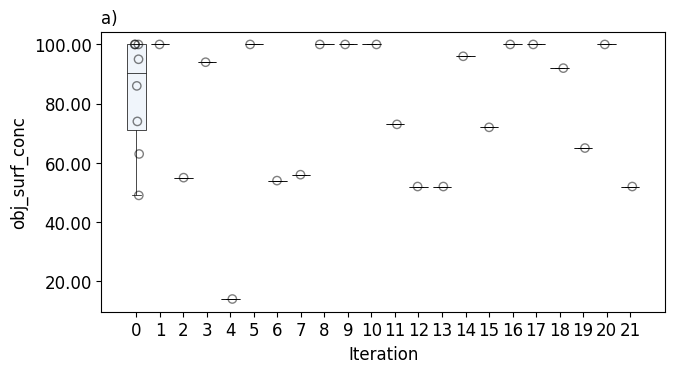

/var/folders/hk/7jjnrbrj53n1t8_bmkhf0_k00000gn/T/ipykernel_3034/3226525103.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/hk/7jjnrbrj53n1t8_bmkhf0_k00000gn/T/ipykernel_3034/3226525103.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticks(), fontsize=fontsize)
/var/folders/hk/7jjnrbrj53n1t8_bmkhf0_k00000gn/T/ipykernel_3034/3226525103.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f'{tick:.2f}' for tick in ax.get_yticks()], fontsize=fontsize)


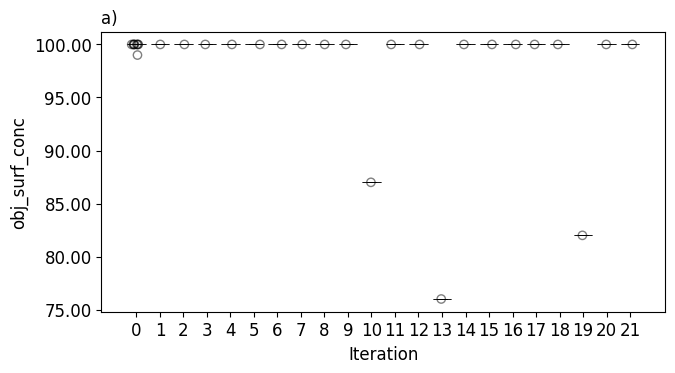

/var/folders/hk/7jjnrbrj53n1t8_bmkhf0_k00000gn/T/ipykernel_3034/3226525103.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/hk/7jjnrbrj53n1t8_bmkhf0_k00000gn/T/ipykernel_3034/3226525103.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticks(), fontsize=fontsize)
/var/folders/hk/7jjnrbrj53n1t8_bmkhf0_k00000gn/T/ipykernel_3034/3226525103.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f'{tick:.2f}' for tick in ax.get_yticks()], fontsize=fontsize)


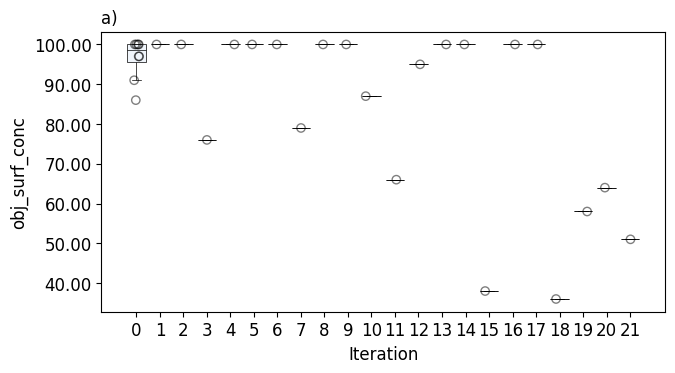

/var/folders/hk/7jjnrbrj53n1t8_bmkhf0_k00000gn/T/ipykernel_3034/3226525103.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/hk/7jjnrbrj53n1t8_bmkhf0_k00000gn/T/ipykernel_3034/3226525103.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticks(), fontsize=fontsize)
/var/folders/hk/7jjnrbrj53n1t8_bmkhf0_k00000gn/T/ipykernel_3034/3226525103.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f'{tick:.2f}' for tick in ax.get_yticks()], fontsize=fontsize)


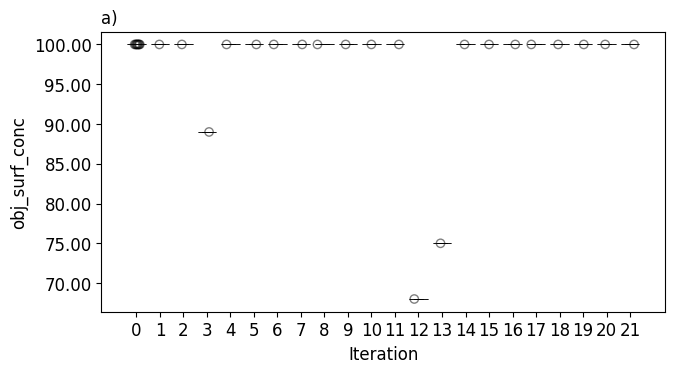

/var/folders/hk/7jjnrbrj53n1t8_bmkhf0_k00000gn/T/ipykernel_3034/3226525103.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/hk/7jjnrbrj53n1t8_bmkhf0_k00000gn/T/ipykernel_3034/3226525103.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticks(), fontsize=fontsize)
/var/folders/hk/7jjnrbrj53n1t8_bmkhf0_k00000gn/T/ipykernel_3034/3226525103.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f'{tick:.2f}' for tick in ax.get_yticks()], fontsize=fontsize)


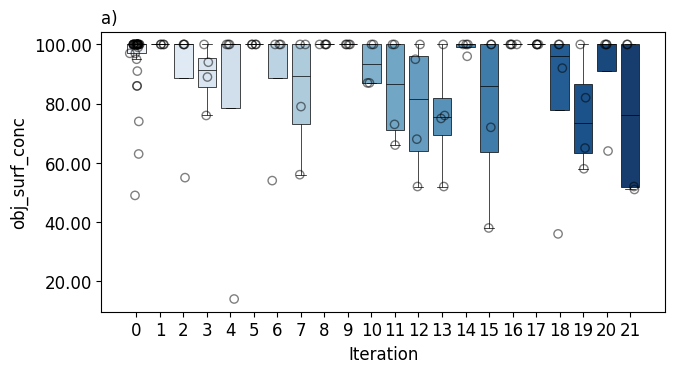

In [55]:
for df_drug in df_drugs:
    data_to_plot = df_drug.copy()


    # plot optimization process as boxplots

    fig = plt.figure(figsize=(16, 8))
    grid = plt.GridSpec(2, 2, wspace=0.2, hspace=0.2)


    ax1 = fig.add_subplot(grid[0, 0])
    boxplot(data_to_plot, 'obj_surf_conc', ax1, 'a)')


    fig.patch.set(facecolor='none')
    #fig.canvas.print_figure('Boxplot.png', dpi=600)
    plt.show()

/var/folders/hk/7jjnrbrj53n1t8_bmkhf0_k00000gn/T/ipykernel_3034/2879373960.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/hk/7jjnrbrj53n1t8_bmkhf0_k00000gn/T/ipykernel_3034/2879373960.py:129: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


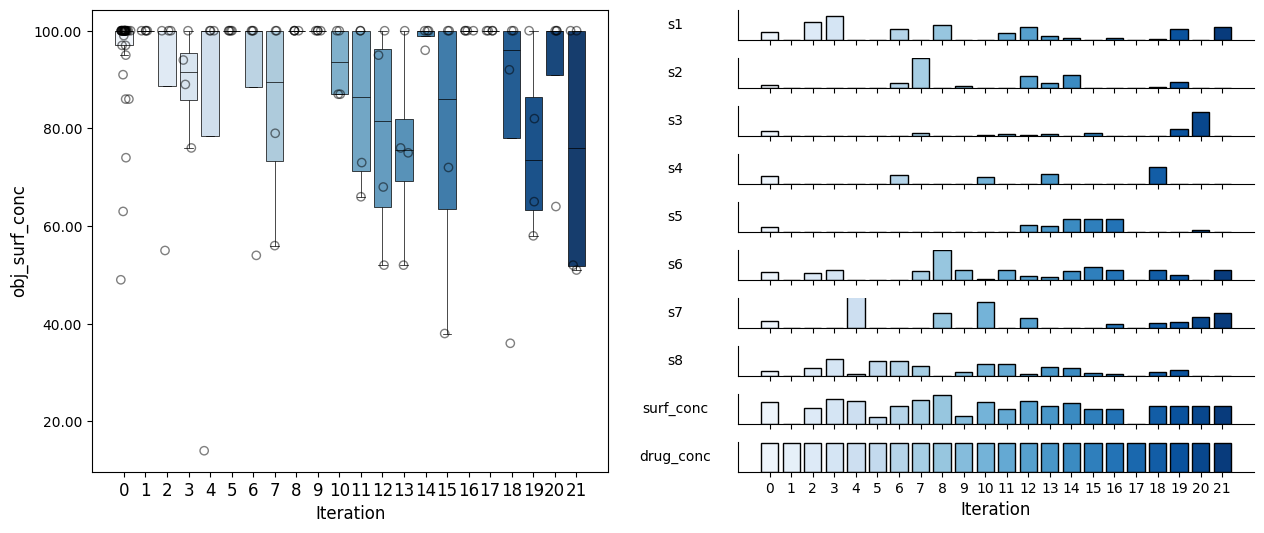

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.ticker as mticker

def boxplot(data, col, ax, ann):
    fontsize = 12
    data = data.copy()
    data['iteration'] = data['iteration'].astype(int)
    iterations = sorted(data['iteration'].unique())
    colors = sns.color_palette("Blues", len(iterations))

    sns.boxplot(
        x='iteration', y=col, data=df,
        order=iterations, palette=colors,
        linewidth=0.5,
        boxprops={'edgecolor':'black'},
        whiskerprops={'color':'black'},
        capprops={'color':'black'},
        medianprops={'color':'black'},
        showfliers=False,
        ax=ax
    )
    for it in iterations:
        sub = data[data['iteration']==it]
        xj = np.random.normal(it, 0.1, size=len(sub))
        ax.scatter(xj, sub[col], facecolors='none',
                   edgecolors='black', alpha=0.5, zorder=3)

    ax.set_ylabel(col, fontsize=fontsize)
    ax.set_xticks(iterations)
    ax.set_xticklabels(iterations, fontsize=fontsize)
    ax.set_xlabel("Iteration", fontsize=fontsize)

    fmt = mticker.FuncFormatter(
        lambda x, _: f'{x:.0f}' if col in ('Size','Complexity') else f'{x:.2f}'
    )
    ax.yaxis.set_major_formatter(fmt)
    ax.annotate(ann, xy=(0,1.08), xycoords='axes fraction',
                ha='left', va='top', fontsize=fontsize)

# --- modified bar function with y-axis spine and label visible ---
def bar(data, param, ax, ann=None):
    fontsize = 10
    data = data.copy()
    data['iteration'] = data['iteration'].astype(int)
    iterations = sorted(data['iteration'].unique())
    means = data.groupby('iteration')[param].mean().reindex(iterations)

    # same palette
    colors = sns.color_palette("Blues", len(iterations))

    # draw bars
    ax.bar(
        iterations,
        means,
        width=0.8,
        color=colors,
        edgecolor='black'
    )

    # show y-axis label
    ax.set_ylabel(param,
                  fontsize=fontsize,
                  rotation=0,
                  labelpad=45,
                  va='center')

    if ann:
        ax.annotate(ann,
                    xy=(0,1.08),
                    xycoords='axes fraction',
                    ha='left', va='top',
                    fontsize=fontsize)

    # fixed limits for s1–s8
    if param in [f's{i}' for i in range(1,9)]:
        ax.set_ylim(0, 50)

    # strip top and right spines only
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    # ensure left spine is visible
    ax.spines['left'].set_visible(True)
    ax.spines['bottom'].set_visible(True)

    # only bottom ticks, no x tick labels by default
    ax.xaxis.set_ticks_position('bottom')
    ax.tick_params(
        axis='x',
        which='both',
        bottom=True,
        labelbottom=False,
        labelsize=fontsize
    )
    # hide y ticks but keep axis line
    ax.tick_params(
        axis='y',
        which='both',
        left=False,
        labelleft=False
    )

# --- build the stacked figure with bars ---
params = ['s1','s2','s3','s4','s5','s6','s7','s8','surf_conc','drug_conc']


fig = plt.figure(figsize=(15, len(params) * 0.6))
boxplot_rows = len(params)
gs = fig.add_gridspec(nrows=len(params), ncols=2, hspace=0.6, wspace=0.25)

# Boxplot at top
ax0 = fig.add_subplot(gs[0:boxplot_rows, 0])
boxplot(df.copy(), 'obj_surf_conc', ax0, ann=None)

# Bars for each parameter
for i, param in enumerate(params):
    ax = fig.add_subplot(gs[i, 1], sharex=ax0)
    bar(df.copy(), param, ax, ann=None)

# label and show tick labels only on the bottommost bar chart
last_ax = fig.axes[-1]
last_ax.set_xlabel('Iteration', fontsize=12)
last_ax.tick_params(axis='x', which='both', labelbottom=True)

# Save the figure
fig.patch.set(facecolor='none')
#fig.canvas.print_figure('hypervolume.png', dpi=600)
plt.tight_layout()
plt.show()


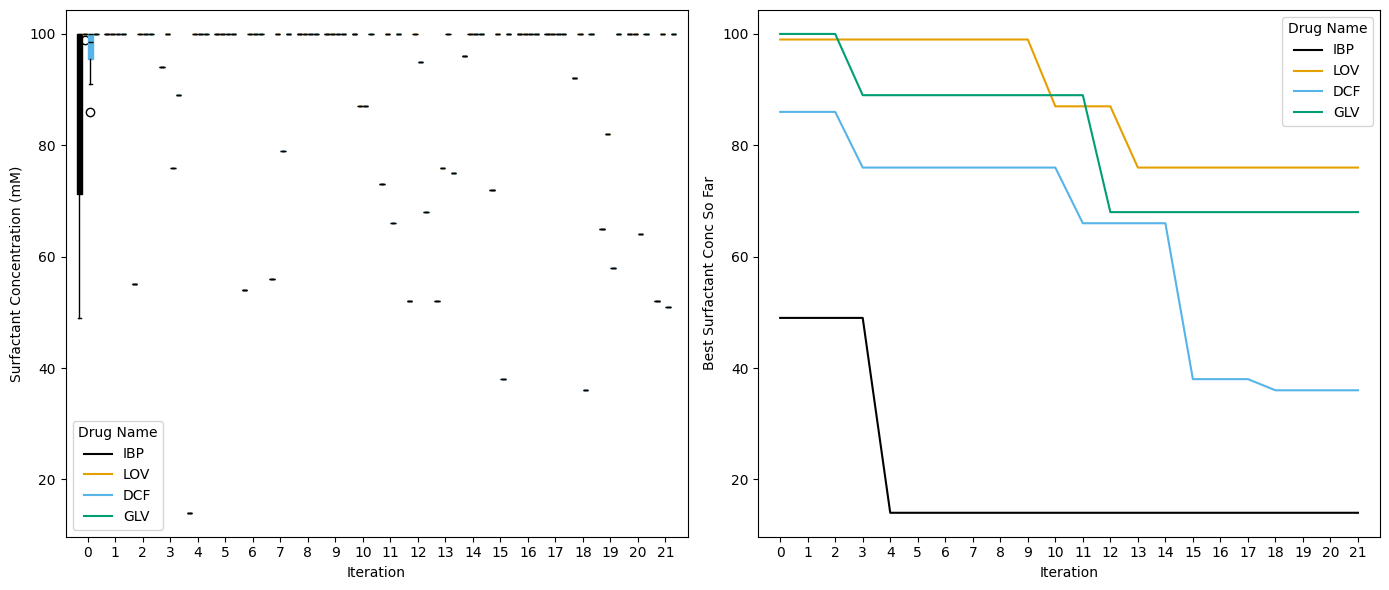

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1) define the Okabe‐Ito (Nature‑recommended) palette
palette = ['#000000','#E69F00','#56B4E9','#009E73',
           '#F0E442','#0072B2','#D55E00','#CC79A7']

# 2) figure out your drugs and colors
drugs = df['drug_name'].unique()
colors = {drug: palette[i] for i, drug in enumerate(drugs)}

# 3) get sorted list of iteration numbers, but we'll plot at positions 0..N‑1
iterations = sorted(df['iteration'].unique())
n_iters = len(iterations)
n_drugs = len(drugs)
ind = np.arange(n_iters)             # 0,1,2,...
width = 0.8 / n_drugs                # total group width

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharex=True)

# — Left: boxplots grouped by iteration-category
for i, drug in enumerate(drugs):
    # collect per-iteration Hypervolume arrays
    data = [
        df.loc[
            (df['drug_name']==drug) & 
            (df['iteration']==it), 
            'obj_surf_conc'
        ].values
        for it in iterations
    ]
    # shift each drug’s boxes within the group
    positions = ind + (i - (n_drugs-1)/2) * width

    ax1.boxplot(
        data, 
        positions=positions, 
        widths=width, 
        patch_artist=True,
        boxprops=dict(facecolor=colors[drug], edgecolor=colors[drug]),
        medianprops=dict(color='black')
    )

ax1.set_xticks(ind)
ax1.set_xticklabels(iterations)
ax1.set_xlabel('Iteration')
ax1.set_ylabel('Surfactant Concentration (mM)')


# Legend
for drug in drugs:
    ax1.plot([], [], color=colors[drug], label=drug)
ax1.legend(title='Drug Name')

# — Right: “best‐so‐far” cumulative max line plot
for drug in drugs:
    dfd = df[df['drug_name']==drug]
  
    conc_min = (
        dfd.groupby('iteration')['obj_surf_conc']
           .min()
           .reindex(iterations, fill_value=np.nan)
           .cummin()
    )
    ax2.plot(ind, conc_min, label=drug, color=colors[drug])

ax2.set_xticks(ind)
ax2.set_xticklabels(iterations)
ax2.set_xlabel('Iteration')
ax2.set_ylabel('Best Surfactant Conc So Far')
#ax2.set_title('Best‐So‐Far Hypervolume per Iteration')
ax2.legend(title='Drug Name')

plt.tight_layout()
plt.show()